In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
output_csv = './results.csv'
output_dir = "./figures/all/"
df = pd.read_csv(f'{output_dir}/{output_csv}')

In [4]:
filtered_df = df[(df['dataset'] == 'Salesforce-wikitext') & (df['step'] == df['step'].max())]
sorted_df = filtered_df.sort_values('mean_metric', ascending=False)

In [16]:
sorted_df['disp_type'].unique()

array(['hinge', 'covariance', 'infonce_cosine', nan, 'infonce_l2'],
      dtype=object)

In [14]:
sorted_df[sorted_df['disp_type'] == 'hinge'].sort_values('mean_metric', ascending=False)

,folder_name,filename,step,dataset,lr,tokens,disp_type,disp_value,tau_cosine,tau_l2,...,"squad_completion,contains,none","boolq,acc,none","piqa,acc_norm,none","arc_easy,acc_norm,none","arc_challenge,acc_norm,none","mmlu,acc,none","medmcqa,acc_norm,none","agieval_en,acc,none","squadv2,exact,none",mean_metric
367,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,0.00001,300000000.0,hinge,1.0,NaN,NaN,...,0.24,0.46,0.62,0.36,0.21,0.255614,0.24,0.238,0.47,0.372495
368,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,0.00001,300000000.0,hinge,0.5,NaN,NaN,...,0.22,0.48,0.60,0.34,0.22,0.254561,0.23,0.236,0.48,0.369236
363,midtrain_gpt2_Salesforce-wikitext_lr-1e-05_tok...,lm_eval_end_1102.json,1102,Salesforce-wikitext,0.00001,300000000.0,hinge,0.1,NaN,NaN,...,0.22,0.48,0.62,0.36,0.22,0.256667,0.26,0.235,0.47,0.367059


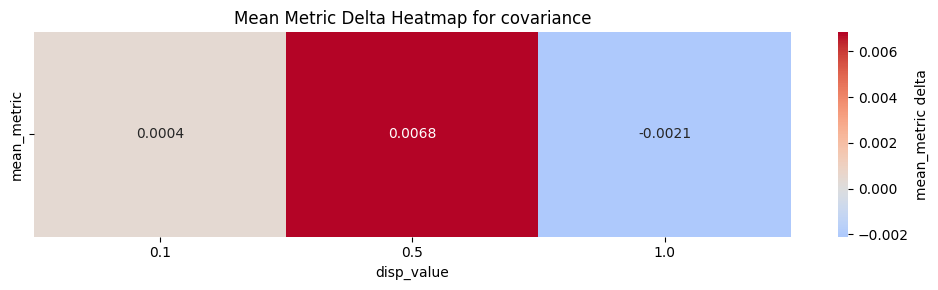

In [39]:
method = 'covariance'
hparam1 = 'disp_value'
infonce_data = sorted_df[sorted_df['disp_type'] == method][[hparam1, 'mean_metric']]
none_data = sorted_df[sorted_df['disp_type'].isna()][['mean_metric']]
assert len(none_data) == 1
none_data = none_data.iloc[0].values[0]
infonce_delta = infonce_data.copy()
infonce_delta['mean_metric'] = infonce_delta['mean_metric'] - none_data

# Handle duplicates by aggregating (taking mean)
pivot_data = infonce_delta.groupby(hparam1)['mean_metric'].mean().reset_index()
# Reshape to 1xN for heatmap visualization
pivot_data_heatmap = pivot_data.set_index(hparam1).T

# Create 1D heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(pivot_data_heatmap, cmap='coolwarm', center=0, annot=True, fmt='.4f', cbar_kws={'label': 'mean_metric delta'})
plt.xlabel(hparam1)
plt.ylabel('')
plt.title(f'Mean Metric Delta Heatmap for {method}')
plt.tight_layout()
plt.show()


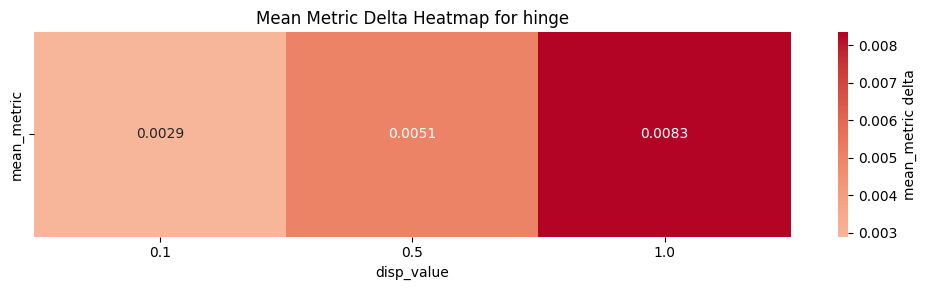

In [40]:
method = 'hinge'
hparam1 = 'disp_value'
infonce_data = sorted_df[sorted_df['disp_type'] == method][[hparam1, 'mean_metric']]
none_data = sorted_df[sorted_df['disp_type'].isna()][['mean_metric']]
assert len(none_data) == 1
none_data = none_data.iloc[0].values[0]
infonce_delta = infonce_data.copy()
infonce_delta['mean_metric'] = infonce_delta['mean_metric'] - none_data

# Handle duplicates by aggregating (taking mean)
pivot_data = infonce_delta.groupby(hparam1)['mean_metric'].mean().reset_index()
# Reshape to 1xN for heatmap visualization
pivot_data_heatmap = pivot_data.set_index(hparam1).T

# Create 1D heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(pivot_data_heatmap, cmap='coolwarm', center=0, annot=True, fmt='.4f', cbar_kws={'label': 'mean_metric delta'})
plt.xlabel(hparam1)
plt.ylabel('')
plt.title(f'Mean Metric Delta Heatmap for {method}')
plt.tight_layout()
plt.show()


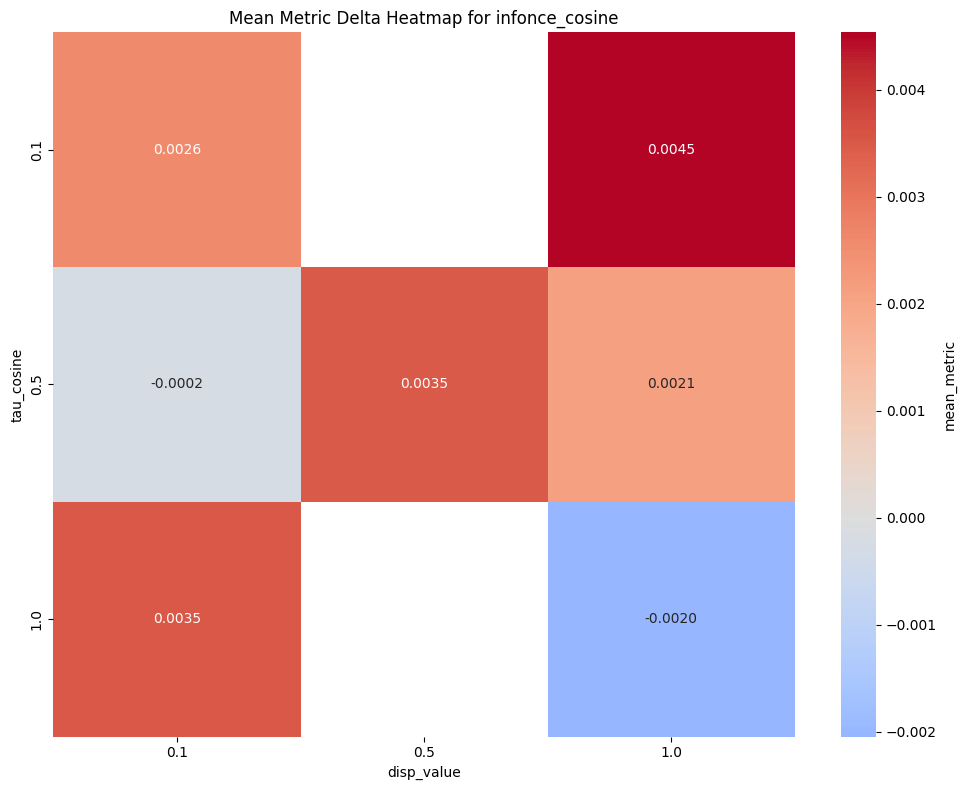

In [36]:
method = 'infonce_cosine'
hparam1 = 'disp_value'
hparam2 = 'tau_cosine'
infonce_data = sorted_df[sorted_df['disp_type'] == method][[hparam1, hparam2, 'mean_metric']]
none_data = sorted_df[sorted_df['disp_type'].isna()][['mean_metric']]
assert len(none_data) == 1
none_data = none_data.iloc[0].values[0]
infonce_delta = infonce_data.copy()
infonce_delta['mean_metric'] = infonce_delta['mean_metric'] - none_data

# Handle duplicates by aggregating (taking mean)
pivot_data = infonce_delta.groupby([hparam2, hparam1])['mean_metric'].mean().reset_index()
pivot_data = pivot_data.pivot(index=hparam2, columns=hparam1, values='mean_metric')

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_data, cmap='coolwarm', center=0, annot=True, fmt='.4f', cbar_kws={'label': 'mean_metric'})
plt.xlabel(hparam1)
plt.ylabel(hparam2)
plt.title(f'Mean Metric Delta Heatmap for {method}')
plt.tight_layout()
plt.show()

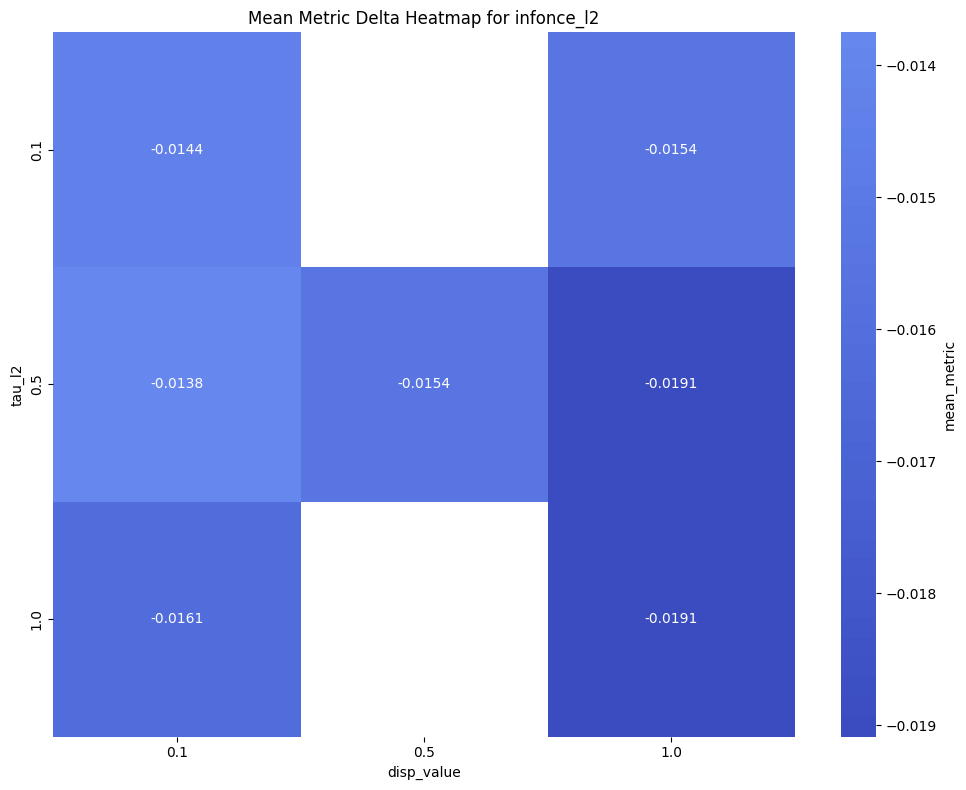

In [37]:
method = 'infonce_l2'
hparam1 = 'disp_value'
hparam2 = 'tau_l2'
infonce_data = sorted_df[sorted_df['disp_type'] == method][[hparam1, hparam2, 'mean_metric']]
none_data = sorted_df[sorted_df['disp_type'].isna()][['mean_metric']]
assert len(none_data) == 1
none_data = none_data.iloc[0].values[0]
infonce_delta = infonce_data.copy()
infonce_delta['mean_metric'] = infonce_delta['mean_metric'] - none_data

# Handle duplicates by aggregating (taking mean)
pivot_data = infonce_delta.groupby([hparam2, hparam1])['mean_metric'].mean().reset_index()
pivot_data = pivot_data.pivot(index=hparam2, columns=hparam1, values='mean_metric')

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_data, cmap='coolwarm', center=0, annot=True, fmt='.4f', cbar_kws={'label': 'mean_metric'})
plt.xlabel(hparam1)
plt.ylabel(hparam2)
plt.title(f'Mean Metric Delta Heatmap for {method}')
plt.tight_layout()
plt.show()

In [ ]:
none_data

mean_metric    0.364157
Name: 348, dtype: float64